In [1]:
%load_ext autoreload
%autoreload 2
import feature_extract
import sys
sys.path.append("..")
import torch
import pickle
from tqdm import tqdm
import numpy as np
import misc_utils.image_utils as imgs
import counterfeit_utils as cfu
import data_retrieval.psql_methods as psql
import multiprocessing
import pandas as pd
import misc_utils.image_utils as imgs
import misc_utils.feature_utils as feat
import matplotlib.pyplot as plt


In [2]:
#We can now create a dataframe with th embeddings of all of th top 100 NFTs
#We assume the features have already been computed by the feature_extract_notebook
model_string = 'dinov2_vits14'
data_path = '/global/scratch/tlundy/NFT_Research/nft_research/Dino/images_features/counterfeit_images'
out_path = f'/global/scratch/tlundy/NFT_Research/nft_research/Dino/images_features/counterfeit_features/{model_string}'
feature_path = out_path+'/testfeat.pth'
features = torch.load(feature_path)
labels = feature_extract.get_labels(data_path)
file_names = feature_extract.get_filenames(data_path)
features_list = features.tolist()
# Create a pandas DataFrame
data = {'Label': labels.tolist(), 'Features': features_list,'Collection':[x[0] for x in file_names],
        'NFT_num':[x[1] for x in file_names]}
df = pd.DataFrame(data)
df = feat.compute_average_vector(df,column='Label')
df

/tmp/ipykernel_661833/1997239614.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  features = torch.load(feature_path)


Dataset ReturnIndexDataset
    Number of datapoints: 60382
    Root location: /global/scratch/tlundy/NFT_Research/nft_research/Dino/images_features/counterfeit_images/val


100%|██████████| 133/133 [00:00<00:00, 143.54it/s]


,Label,Features,Collection,NFT_num,AverageFeatureVector
0,0,"[0.06834631413221359, 0.013368001207709312, 0....",0n1-force,1010,"[0.05036659871786995, -0.013276008738578319, 0..."
1,0,"[0.08093642443418503, -0.03803253173828125, 0....",0n1-force,1012,"[0.05036659871786995, -0.013276008738578319, 0..."
2,0,"[0.028013398870825768, -0.02013389579951763, 0...",0n1-force,1025,"[0.05036659871786995, -0.013276008738578319, 0..."
3,0,"[-0.03390040993690491, 0.004265990108251572, 0...",0n1-force,1034,"[0.05036659871786995, -0.013276008738578319, 0..."
4,0,"[0.026579292491078377, -0.014232189394533634, ...",0n1-force,1044,"[0.05036659871786995, -0.013276008738578319, 0..."
...,...,...,...,...,...
60377,132,"[-0.06007155403494835, 0.01303652860224247, 0....",zombieclub-token,952,"[-0.007146694796058, 0.0027466976506839275, 0...."
60378,132,"[0.008216793648898602, 0.007785656955093145, -...",zombieclub-token,956,"[-0.007146694796058, 0.0027466976506839275, 0...."
60379,132,"[-0.03259636461734772, 0.01624414138495922, 0....",zombieclub-token,964,"[-0.007146694796058, 0.0027466976506839275, 0...."
60380,132,"[0.05409884452819824, -0.014129256829619408, -...",zombieclub-token,989,"[-0.007146694796058, 0.0027466976506839275, 0...."


In [3]:
#Next we load the dataframe containing embeddings of all other collection
df2 = pd.read_pickle('archive/graph_images_dataframe.pkl')
df2

,Label,Features,Collection,NFT_num,AverageFeatureVector
0,0,"[0.006129133980721235, 0.08498869091272354, -0...",-glowa-,1,"[-0.007021066558081657, 0.034550966462120414, ..."
1,0,"[0.04774976521730423, 0.05362828075885773, 0.0...",-glowa-,10017,"[-0.007021066558081657, 0.034550966462120414, ..."
2,0,"[0.10529650747776031, 0.07033471018075943, 0.0...",-glowa-,10018,"[-0.007021066558081657, 0.034550966462120414, ..."
3,0,"[-0.02233046293258667, 0.01190363708883524, -0...",-glowa-,10019,"[-0.007021066558081657, 0.034550966462120414, ..."
4,0,"[0.04859286919236183, 0.054554957896471024, 0....",-glowa-,10024,"[-0.007021066558081657, 0.034550966462120414, ..."
...,...,...,...,...,...
456139,10976,"[-0.033141832798719406, -0.0350814163684845, -...",zzz-zzz-by-hashlips,75,"[-0.033141832798719406, -0.0350814163684845, -..."
456140,10976,"[-0.033141832798719406, -0.0350814163684845, -...",zzz-zzz-by-hashlips,77,"[-0.033141832798719406, -0.0350814163684845, -..."
456141,10976,"[-0.033141832798719406, -0.0350814163684845, -...",zzz-zzz-by-hashlips,78,"[-0.033141832798719406, -0.0350814163684845, -..."
456142,10976,"[-0.033141832798719406, -0.0350814163684845, -...",zzz-zzz-by-hashlips,79,"[-0.033141832798719406, -0.0350814163684845, -..."


In [7]:
#combine the two dataframes and drop duplicate collections
df_combined = pd.concat([df, df2], ignore_index=True)
df_combined = df_combined.drop_duplicates(subset=['Collection'])
command = "Select * from collection_total_stats"
temp_stats_tuples = psql.execute_commands([command])
df_stats = pd.DataFrame(temp_stats_tuples,columns = ['volume','sales', 'avg_price','num_owners','market_cap','floor','symbol','Collection'])
#merge df_combined with df_stats on Collection
df_combined = df_combined.merge(df_stats, on='Collection', how='left')
#drop rows with missing values in the stats columns
df_combined = df_combined.dropna(subset=['volume', 'sales', 'avg_price', 'num_owners', 'market_cap', 'floor'])
df_combined

,Label,Features,Collection,NFT_num,AverageFeatureVector,volume,sales,avg_price,num_owners,market_cap,floor,symbol
0,0,"[0.06834631413221359, 0.013368001207709312, 0....",0n1-force,1010,"[0.05036659871786995, -0.013276008738578319, 0...",85523.399799,53569.0,1.596509,3690.0,7746.399318,1.019998,ETH
2,1,"[-0.05611144006252289, -0.014044423587620258, ...",3landers,1006,"[-0.04630318949784851, -0.010081826161956997, ...",36364.856276,31008.0,1.172757,5105.0,300.784032,0.028199,ETH
3,2,"[-0.0729079470038414, 0.0296789538115263, -0.0...",acclimatedmooncats,10017,"[-0.039492317732423544, -0.0006221182154417875...",21812.936297,25933.0,0.841127,5605.0,4178.143338,0.197900,ETH
4,3,"[0.001956846797838807, 0.02038602903485298, -0...",adidasoriginals,0,"[-0.016449052724055946, 0.02894655242562294, -...",49290.542643,50573.0,0.974641,7730.0,0.102618,0.046000,ETH
5,4,"[-0.11060408502817154, 0.022503795102238655, -...",akidcalledbeast,1015,"[-0.09360162493959069, 0.031058840463287198, -...",21295.323929,29560.0,0.720410,3413.0,2732.390902,0.278000,ETH
...,...,...,...,...,...,...,...,...,...,...,...,...
10982,10972,"[-0.03123331256210804, 0.003685231087729335, -...",zunkpets,10031,"[-0.043920986556913705, 0.004254778374452144, ...",27.055308,827.0,0.032715,897.0,26.555443,0.008000,ETH
10983,10973,"[0.019712116569280624, 0.03712386265397072, -0...",zunkz,19415,"[-0.002928928262554109, 0.01807572929188609, -...",2269.067503,19791.0,0.114651,3405.0,199.741636,0.021399,ETH
10984,10974,"[-0.08353906869888306, -0.020003166049718857, ...",zuphioh-editions,1,"[-0.07176712848660019, -0.012588592763576243, ...",5.072300,37.0,0.137089,260.0,0.000000,0.020000,ETH
10985,10975,"[-0.060884226113557816, 0.008285006508231163, ...",zuttomamoru,15048,"[-0.1024509184807539, 0.018767129573971034, -0...",7.118630,361.0,0.019719,1127.0,0.000000,0.009500,ETH


/global/scratch/tlundy/NFT_Research/nft_venv2/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


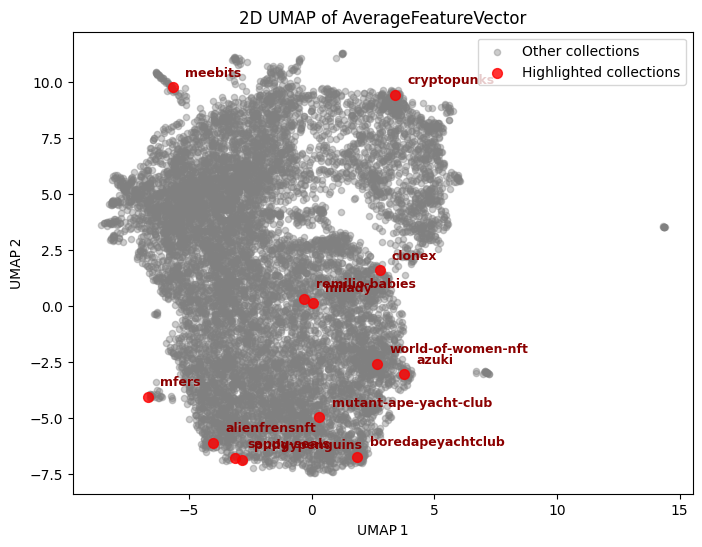

In [138]:
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt

# 1) prepare data
X = np.vstack(df_combined['AverageFeatureVector'].values)
reducer = umap.UMAP(n_components=2,
                    n_neighbors=15,
                    min_dist=0.5,    
                    spread=1.5,
                    metric='euclidean',
                    random_state=42)
X_2d = reducer.fit_transform(X)

df_embed = pd.DataFrame({
    'UMAP1':     X_2d[:, 0],
    'UMAP2':     X_2d[:, 1],
    'collection': df_combined['Collection'].values
})
highlight_set = set(df['Collection'])
highlight_set = set(['boredapeyachtclub', 'cryptopunks', 'azuki', 'doodles', 'moonbirds', 'worldofwomen', 'clonex', 'meebits','milady','mutant-ape-yacht-club','remilio-babies','world-of-women-nft','sappy-seals','pudgypenguins','alienfrensnft','mfers'])
df_embed['highlight'] = df_embed['collection'].isin(highlight_set)

# 2) plot base scatter
plt.figure(figsize=(8, 6))
mask_others = ~df_embed['highlight']
plt.scatter(df_embed.loc[mask_others, 'UMAP1'],
            df_embed.loc[mask_others, 'UMAP2'],
            s=20, alpha=0.4, label='Other collections', color='gray')

mask_high = df_embed['highlight']
plt.scatter(df_embed.loc[mask_high, 'UMAP1'],
            df_embed.loc[mask_high, 'UMAP2'],
            s=50, alpha=0.8, label='Highlighted collections', color='red')

# 3) add labels for the highlighted points
for _, row in df_embed[mask_high].iterrows():
    plt.text(row['UMAP1'] + 0.5,   # small x-offset so text doesn’t sit directly on the dot
             row['UMAP2'] + 0.5,   # small y-offset
             row['collection'],
             fontsize=9,
             weight='bold',
             color='darkred')

plt.legend()
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('2D UMAP of AverageFeatureVector')
plt.show()

In [136]:
overlaps = cfu.count_overlaps('mfers')
overlaps['row_count'] = np.log1p(overlaps['row_count'])
# overlaps = overlaps.query('row_count > 0')

/global/scratch/tlundy/NFT_Research/nft_venv2/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_967186/2098247079.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('Blues')
/tmp/ipykernel_967186/2098247079.py:70: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cb = plt.colorbar(sm)


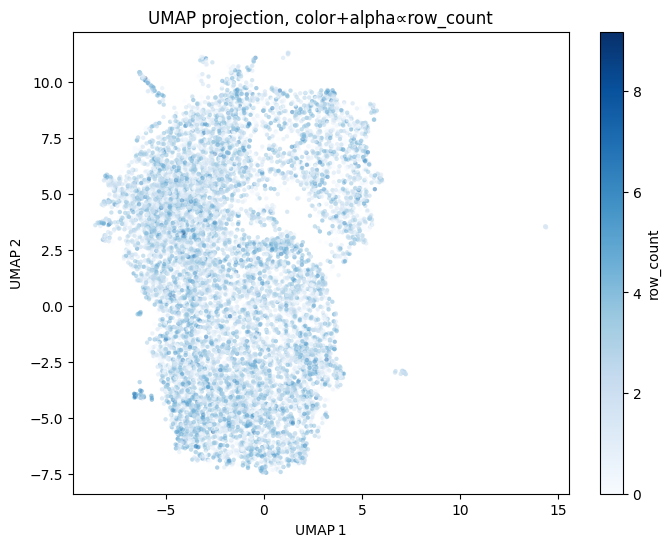

In [137]:
import numpy as np
import pandas as pd
import umap
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

#upper bound overlaps row count by 1000
# overlaps['row_count'] = np.clip(overlaps['row_count'], 0, 200)

# — 1) build your embedding as before —
X = np.vstack(df_combined['AverageFeatureVector'].values)
reducer = umap.UMAP(n_components=2,
                    n_neighbors=15,
                    min_dist=0.5,
                    spread=1.5,
                    metric='euclidean',
                    random_state=42)
X_2d = reducer.fit_transform(X)
df_embed = pd.DataFrame({
    'UMAP1':     X_2d[:, 0],
    'UMAP2':     X_2d[:, 1],
    'Collection': df_combined['Collection'].values
})

# — 2) merge in row_count (fill missing with 0) —
df_embed = df_embed.merge(
    overlaps.rename(columns={'slug':'Collection'}),
    on='Collection',
    how='left'
)
df_embed['row_count'] = df_embed['row_count'].fillna(0).astype(float)

# — 3) normalize counts for color & alpha —
counts = df_embed['row_count']
norm   = Normalize(vmin=counts.min(), vmax=counts.max())

# get RGBA colors from a colormap:
cmap = cm.get_cmap('Blues')
colors = cmap(norm(counts))  # shape (n, 4)

# now overwrite the alpha channel (colors[:,3]) with a scaled version of counts:
# choose a min and max alpha you like:
# min_alpha, max_alpha = 0.01, 1.0
# alphas = min_alpha + (counts / counts.max()) * (max_alpha - min_alpha)
# colors[:, 3] = alphas

# # — 4) (optional) also scale sizes by count:
# min_s, max_s = 20, 200
# sizes = min_s + (counts / counts.max()) * (max_s - min_s)

# — 5) plot with per-point RGBA colors —
plt.figure(figsize=(8,6))
plt.scatter(
    df_embed['UMAP1'],
    df_embed['UMAP2'],
    c=colors,     # pass the RGBA array
    s=10,      # or a fixed number if you prefer
    edgecolors='none',
    alpha=0.5
)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP projection, color+alpha∝row_count')
# plt.xlim(-5,5)
# plt.ylim(-4,7)
# (optional) add a colorbar for the base colormap:
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = plt.colorbar(sm)
cb.set_label('row_count')
# plt.xlim(-7, 7)
plt.show()


/tmp/ipykernel_967186/3841601459.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap   = cm.get_cmap('viridis')  # or any other colormap you like
/tmp/ipykernel_967186/3841601459.py:35: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cb = plt.colorbar(sm, ticks=[0,0.25,0.5,0.75,1.0])


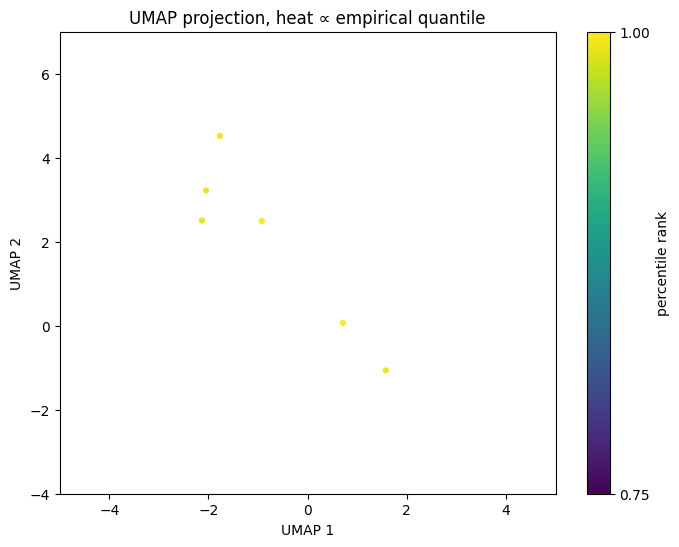

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

# — assume df_embed has UMAP1, UMAP2, and row_count columns already —
# 1) compute the percentile rank (0–1)
df_embed['quantile'] = df_embed['row_count'].rank(pct=True)
df_embed = df_embed.query('quantile > 0.99')  # remove zero quantiles
# 2) turn that into RGBA via a colormap
norm   = Normalize(vmin=0.75, vmax=1.0)        # since quantile ∈ [0,1]
cmap   = cm.get_cmap('viridis')  # or any other colormap you like
colors = cmap(norm(df_embed['quantile']))

# 3) set alpha = quantile (or scale into [min_alpha,max_alpha])
colors[:, 3] = 0 + (df_embed['quantile'] * (1.0 - 0))



# 5) plot
plt.figure(figsize=(8,6))
sc = plt.scatter(
    df_embed['UMAP1'], df_embed['UMAP2'],
    c=colors, s=20, edgecolors='none'
)
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP projection, heat ∝ empirical quantile')
# colorbar in quantile units
plt.xlim(-5,5)
plt.ylim(-4,7)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cb = plt.colorbar(sm, ticks=[0,0.25,0.5,0.75,1.0])
cb.set_label('percentile rank')
plt.show()

In [5]:
def plot_collection_distance(
    df: pd.DataFrame,
    target: str,
    *,
    collection_col: str = "Collection",
    feature_col: str = "AverageFeatureVector",
    price_col: str = "avg_price",
    count_col: str = "row_count",
    cmap: str = "viridis" ,
    plot_kind: str = "scatter",     # "scatter" or "hexbin"
    hex_gridsize: int = 60,         # only used if plot_kind=="hexbin"
    hex_stat: str = "mean",  
    only_lower = False        # any Matplotlib colormap you like
):
    """
    Scatter‑plots Euclidean distance in embedding space vs. price difference
    relative to `target`, with points coloured by `row_count`.

    Parameters
    ----------
    df : DataFrame containing at least the columns listed below.
    target : Name of the collection you want as the reference point.
    collection_col, feature_col, price_col, count_col : str
        Column names (override if yours differ).
    cmap : Matplotlib colormap.
    """
    # --- 1. Locate the reference row ----------------------------------------
    try:
        ref_row = df.loc[df[collection_col] == target].iloc[0]
    except IndexError:
        raise ValueError(f"Collection '{target}' not found in column "
                         f"'{collection_col}'")

    ref_vec      = np.asarray(ref_row[feature_col])
    ref_price    = ref_row[price_col]
    overlaps = cfu.count_overlaps(target)
    overlaps['row_count'] = np.log1p(overlaps['row_count'])
    df = df.merge(
    overlaps.rename(columns={'slug':'Collection'}),
    on='Collection',
    how='left'
    )
    df['row_count'] = df['row_count'].fillna(0).astype(float)
    df['price_diff'] = df[price_col] - ref_price

    if only_lower:
        df = df.query('price_diff < 0')
    price_diff = df['price_diff'].values
    # --- 2. Prepare embedding matrix and compute distances ------------------
    # If the embedding column already holds arrays/lists of equal length,
    # just stack them; otherwise convert/parse as needed.
    M = np.vstack(df[feature_col].apply(np.asarray).values)  # shape (n, d)
    dists = np.linalg.norm(M - ref_vec, axis=1)

    # --- 3. Price difference and colour values ------------------------------
    
    df['pct_owners'] = df['row_count']
    df['quantile'] = df['pct_owners'].rank(pct=True)
    colours    = df['quantile']   # mapped directly to a colour scale

    mask = df[collection_col] != target         # <‑‑ only non‑target rows
    dists, price_diff, colours = dists[mask], price_diff[mask], colours[mask]
  

    # --- plotting ---------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5))

    if plot_kind in {"hexbin","both"}:
        # choose a reducer for multiple points that fall in the same hex
        reducer = np.mean if hex_stat == "mean" else np.sum
        hb = plt.hexbin(
            dists, price_diff,
            C=colours,
            reduce_C_function=reducer,
            gridsize=hex_gridsize,
            cmap=cmap,
            bins=None,          # colour = reduced row_count, not log‑density
        )
        cb = plt.colorbar(hb)
    if plot_kind in {"scatter", "both"}:
        sc = ax.scatter(
            dists, price_diff, c=colours,
            cmap=cmap,
            s=15,
            alpha=0.8,
            edgecolor="white",
            linewidth=0.3
        )
        if plot_kind == "scatter":          # give scatter its own colourbar
            cb = fig.colorbar(sc, ax=ax, label=count_col)
            cb.set_label(count_col)
    plt.axhline(0, lw=1, ls="--", color="grey")

    plt.xlabel(f"Euclidean distance from “{target}”")
    plt.ylabel(f"Δ price vs. “{target}”")
    plt.title("Distance–Price landscape for collections")
    plt.tight_layout()
    plt.show()

    # --- 5. Optionally return the computed values ---------------------------
    out = df[[collection_col]].copy()
    out["distance"]    = dists
    out["price_diff"]  = price_diff
    out["row_count"]   = colours
    return out

/tmp/ipykernel_153675/2618129458.py:57: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pct_owners'] = df['row_count']
/tmp/ipykernel_153675/2618129458.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['quantile'] = df['pct_owners'].rank(pct=True)


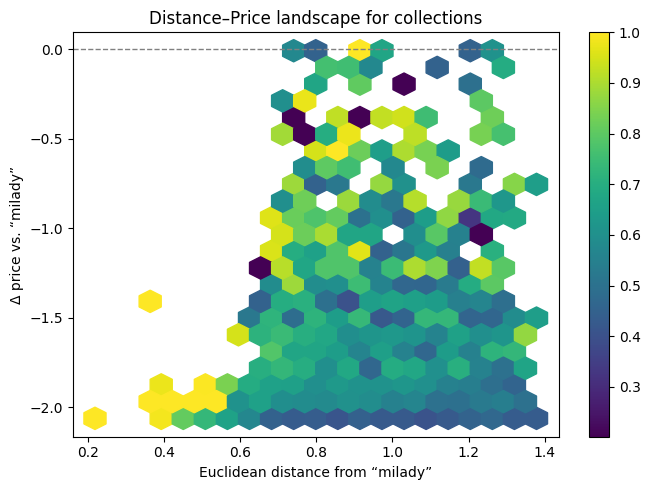

,Collection,distance,price_diff,row_count
0,0n1-force,0.858566,-0.465610,0.976839
1,3landers,0.741274,-0.889362,0.864414
2,acclimatedmooncats,1.101903,-1.220993,0.993340
3,adidasoriginals,1.113493,-1.087478,0.867396
4,akidcalledbeast,0.745441,-1.341709,0.921968
...,...,...,...,...
10146,zunkpets,0.955522,-2.029404,0.201392
10147,zunkz,1.010903,-1.947468,0.201392
10148,zuphioh-editions,0.747672,-1.925030,0.201392
10149,zuttomamoru,0.991256,-2.042400,0.201392


In [72]:
plot_collection_distance(df_combined,'milady',plot_kind="hexbin",hex_gridsize=20,only_lower=True)

In [34]:
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
from scipy import stats
def compute_count_vis_pearson(
    df, target,remove_ders=True,log_vals = False        # <–– NEW flag
):
    """If `equal_counts=True` bins are sized so every bin has ~the same # points."""
    # 1. locate reference
    ref_row   = df.loc[df['Collection'] == target].iloc[0]
    ref_vec   = np.asarray(ref_row['AverageFeatureVector'])
    overlaps = cfu.count_non_top_overlaps(target)
    if log_vals:
        overlaps['row_count'] = np.log1p(overlaps['row_count'])
    df = df.merge(
    overlaps.rename(columns={'slug':'Collection'}),
    on='Collection',
    how='left'
    )
    print(len(df))
    if remove_ders:
        der_list = cfu.der_list_from_db(target)
        print(der_list)
        df = df.query(f"Collection not in {der_list}")
    df['row_count'] = df['row_count'].fillna(0).astype(float)
    df['quantile'] = df['row_count'].rank(pct=True)
    # 2. compute x & y
    M     = np.vstack(df['AverageFeatureVector'].apply(np.asarray).values)
    x     = np.linalg.norm(M - ref_vec, axis=1)        # distance      # Δ price
    X_price = df[['avg_price']].values.reshape(-1, 1)
    y_dist  = x

    lm_dist = LinearRegression().fit(X_price, y_dist)
    pred_dist = lm_dist.predict(X_price)
    resid_dist = y_dist - pred_dist

    # 2. Fit counts ~ price, get residuals
    y_count = df['row_count'].values

    lm_count = LinearRegression().fit(X_price, y_count)
    pred_count = lm_count.predict(X_price)
    resid_count = y_count - pred_count
    #compute pearson correlation
    corr_partial = pd.Series(resid_dist).corr(pd.Series(resid_count))
    r = corr_partial
    n = len(df)  
    df_dof = n - 3                           # since we controlled for 1 variable (price), df = n - 3

    # Compute the t‐statistic for the partial correlation
    t_stat = r * np.sqrt(df_dof / (1 - r**2))

    # Two‐tailed p‐value
    p_val = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=df_dof))
    corr_pearson,p_val_pear = pearsonr(y_dist, y_count)
    return corr_partial,p_val,corr_pearson,p_val_pear



In [36]:
#get top slugs
top_slugs = df_combined['Collection'].unique()
for slug in top_slugs:
    # try:
    #     print(slug,compute_count_vis_pearson(df_combined, slug,remove_ders=False))
    # except:
    #     print(slug, "Error computing Pearson correlation")
    #     continue
    print(slug,compute_count_vis_pearson(df_combined, slug,remove_ders=False))


10151
0n1-force (-0.09118570990103765, 0.0, -0.0884283283737512, 4.427378177220072e-19)


KeyboardInterrupt: 

In [54]:
df_test = df_combined.copy()

In [56]:
der_list = cfu.der_list_from_db('3landers')
print(der_list)
df_test = df_test.query(f"Collection not in {der_list}")
df_test

['']


,Label,Features,Collection,NFT_num,AverageFeatureVector,volume,sales,avg_price,num_owners,market_cap,floor,symbol
0,0,"[0.06834631413221359, 0.013368001207709312, 0....",0n1-force,1010,"[0.05036659871786995, -0.013276008738578319, 0...",85523.399799,53569.0,1.596509,3690.0,7746.399318,1.019998,ETH
2,1,"[-0.05611144006252289, -0.014044423587620258, ...",3landers,1006,"[-0.04630318949784851, -0.010081826161956997, ...",36364.856276,31008.0,1.172757,5105.0,300.784032,0.028199,ETH
3,2,"[-0.0729079470038414, 0.0296789538115263, -0.0...",acclimatedmooncats,10017,"[-0.039492317732423544, -0.0006221182154417875...",21812.936297,25933.0,0.841127,5605.0,4178.143338,0.197900,ETH
4,3,"[0.001956846797838807, 0.02038602903485298, -0...",adidasoriginals,0,"[-0.016449052724055946, 0.02894655242562294, -...",49290.542643,50573.0,0.974641,7730.0,0.102618,0.046000,ETH
5,4,"[-0.11060408502817154, 0.022503795102238655, -...",akidcalledbeast,1015,"[-0.09360162493959069, 0.031058840463287198, -...",21295.323929,29560.0,0.720410,3413.0,2732.390902,0.278000,ETH
...,...,...,...,...,...,...,...,...,...,...,...,...
10982,10972,"[-0.03123331256210804, 0.003685231087729335, -...",zunkpets,10031,"[-0.043920986556913705, 0.004254778374452144, ...",27.055308,827.0,0.032715,897.0,26.555443,0.008000,ETH
10983,10973,"[0.019712116569280624, 0.03712386265397072, -0...",zunkz,19415,"[-0.002928928262554109, 0.01807572929188609, -...",2269.067503,19791.0,0.114651,3405.0,199.741636,0.021399,ETH
10984,10974,"[-0.08353906869888306, -0.020003166049718857, ...",zuphioh-editions,1,"[-0.07176712848660019, -0.012588592763576243, ...",5.072300,37.0,0.137089,260.0,0.000000,0.020000,ETH
10985,10975,"[-0.060884226113557816, 0.008285006508231163, ...",zuttomamoru,15048,"[-0.1024509184807539, 0.018767129573971034, -0...",7.118630,361.0,0.019719,1127.0,0.000000,0.009500,ETH


In [51]:
df_test = df_test.query('Collection =="0n1-frame"')
df_test

,Label,Features,Collection,NFT_num,AverageFeatureVector,volume,sales,avg_price,num_owners,market_cap,floor,symbol


In [21]:
df_combined.tail(100)

,Label,Features,Collection,NFT_num,AverageFeatureVector,volume,sales,avg_price,num_owners,market_cap,floor,symbol
10885,10874,"[0.026794392615556717, -0.007330227643251419, ...",z-huge,100,"[0.01799931183719309, 0.017206989718397382, 0....",788.761073,1241.0,0.635585,280.0,0.000000,0.119989,ETH
10886,10875,"[0.0010575150372460485, 0.0014245728962123394,...",z00tz-anchor-club,8260,"[0.02925241876160726, 0.002711019144626334, 0....",234.552593,3940.0,0.059531,745.0,421.912630,0.021000,ETH
10887,10876,"[0.013065936043858528, 0.02981974184513092, 0....",z1-serum,0,"[0.013065936043858528, 0.02981974184513092, 0....",108.934874,1365.0,0.079806,623.0,0.000000,0.010000,ETH
10888,10877,"[0.054104238748550415, -0.008125773631036282, ...",zach-punk,1452,"[0.0005444454017560929, 0.016122151283198036, ...",1.992742,472.0,0.004222,1299.0,0.000000,0.009000,ETH
10889,10878,"[-0.07423074543476105, 0.03733755648136139, -0...",zachxbtdefensefund,1,"[-0.07423074543476105, 0.03733755648136139, -0...",0.041500,5.0,0.008300,509.0,0.000000,0.006900,ETH
...,...,...,...,...,...,...,...,...,...,...,...,...
10982,10972,"[-0.03123331256210804, 0.003685231087729335, -...",zunkpets,10031,"[-0.043920986556913705, 0.004254778374452144, ...",27.055308,827.0,0.032715,897.0,26.555443,0.008000,ETH
10983,10973,"[0.019712116569280624, 0.03712386265397072, -0...",zunkz,19415,"[-0.002928928262554109, 0.01807572929188609, -...",2269.067503,19791.0,0.114651,3405.0,199.741636,0.021399,ETH
10984,10974,"[-0.08353906869888306, -0.020003166049718857, ...",zuphioh-editions,1,"[-0.07176712848660019, -0.012588592763576243, ...",5.072300,37.0,0.137089,260.0,0.000000,0.020000,ETH
10985,10975,"[-0.060884226113557816, 0.008285006508231163, ...",zuttomamoru,15048,"[-0.1024509184807539, 0.018767129573971034, -0...",7.118630,361.0,0.019719,1127.0,0.000000,0.009500,ETH


In [20]:
command = "Select distinct slug from slug_to_token"
temp_stats_tuples = psql.execute_commands([command])
temp_stats_tuples = [x[0] for x in temp_stats_tuples]
#compare with slugs from df_combined
temp_stats_tuples = set(temp_stats_tuples)
df_combined_slugs = set(df_combined['Collection'].unique())
missing_slugs =  df_combined_slugs - temp_stats_tuples 
print("Missing slugs:", missing_slugs)

Missing slugs: {'zombiecat', 'zuttomamoru', 'zoofrenznft', 'zscogbeta', 'zoo-manticket', 'zora', 'zoofrenz-apefrenz-utility', 'zoomershigh', 'zombiefrens', 'zora-zine-print-issue-001', 'zoo-jam-gorge', 'zunkpets', 'zuckbots', 'zombietown-wtf-official', 'zoom-by-reo-cragun', 'zomzuki', 'zuphioh-editions', 'zotox', 'zorgex', 'zooversegenesis', 'zto-cover-art', 'zombiepod-genesis', 'mittaria-genesis-1', 'makersplace', 'zooversegenesisstakingnfts', 'lumi-paradox', 'zuckcorpitems', 'zombieclub-token', 'zuki-gen-official', 'zoodlers', 'zombie-apes-official-nft', 'zukiblowon', 'zombie-nfts-by-braindom', 'zoofrenz-first-class-pass', 'psybot', 'known-origin', 'zunkz', 'zoo-manfreemint-1', 'zukibears', 'zombiemonkeys', 'zuki-club-1', 'zscogalpha', 'zombified-humans', 'zombie-lab-pass', 'yayo-nft', 'zombie-bats', 'zone-harmonics-by-chris-mccully', 'zompets', 'superrare', 'cometh-spaceships', 'zoo-of-neural-automata', 'sarugami', 'zoofrenz-apefrenz-2-0', 'zzz-zzz-by-hashlips', 'e9art', 'zoogangnft

In [37]:
import cf_ownership as cfo
cfo.compute_count_vis_pearson(
    df_combined, '0n1-force',remove_ders=False,log_vals = False        # <–– NEW flag
)

(-0.09118570990103765, 0.0, -0.0884283283737512, 4.427378177220072e-19)

In [41]:
df_combined.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
Index: 10151 entries, 0 to 10986
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Label                 10151 non-null  int64  
 1   Features              10151 non-null  object 
 2   Collection            10151 non-null  object 
 3   NFT_num               10151 non-null  object 
 4   AverageFeatureVector  10151 non-null  object 
 5   volume                10151 non-null  float64
 6   sales                 10151 non-null  float64
 7   avg_price             10151 non-null  float64
 8   num_owners            10151 non-null  float64
 9   market_cap            10151 non-null  float64
 10  floor                 10151 non-null  float64
 11  symbol                10151 non-null  object 
dtypes: float64(6), int64(1), object(5)
memory usage: 34.0 MB


In [43]:
import os
import pandas as pd

# directory containing your .pkl files
dir_path = "own_corr"

# collect all DataFrames
dfs = []
for fname in os.listdir(dir_path):
    if fname.startswith("result_df") and fname.endswith(".pkl"):
        full_path = os.path.join(dir_path, fname)
        df = pd.read_pickle(full_path)
        dfs.append(df)

# concatenate into one big DataFrame
big_df = pd.concat(dfs, ignore_index=True)

# optional: inspect or save
print(big_df.shape)

(4794, 2)


In [47]:
expanded = big_df['Pearson_Correlation'].apply(pd.Series)
expanded.columns = ['controled','controled_p','pearson','pearson_p']  # rename the new columns

# merge back
big_df = big_df.join(expanded).drop(columns=['Pearson_Correlation'])
big_df

,Collection,controled,controled_p,pearson,pearson_p
0,burningsouls,-0.001824,8.542320e-01,-0.001952,8.440740e-01
1,burnout-bots-parts-v2,-0.084223,0.000000e+00,-0.084983,9.767288e-18
2,burnt-boy-by-deeze-x-goonz,0.016831,8.996505e-02,0.017225,8.268120e-02
3,bursted-bubbles-by-deblock,-0.033126,8.441219e-04,-0.032515,1.051175e-03
4,bury-nft,-0.048678,9.273035e-07,-0.049748,5.310471e-07
...,...,...,...,...,...
4789,cometh-spaceships,NaN,NaN,NaN,NaN
4790,comfyland,-0.118215,0.000000e+00,-0.119569,1.210617e-33
4791,commoners-by-commonopoly,-0.127253,0.000000e+00,-0.127818,3.069727e-38
4792,commsaur,-0.108998,0.000000e+00,-0.109309,2.321738e-28


In [54]:
# Boolean mask for both conditions
mask = (big_df['controled_p'] < 0.05) & (big_df['controled'] < 0)

# Method 1: mean of the mask gives fraction True
percent = mask.mean() * 100
print(f"{percent:.2f}% of rows have col1 < 0.05 and col2 < 0")

83.06% of rows have col1 < 0.05 and col2 < 0


In [57]:
big_df[mask]['controled'].mean()

-0.09029204704176817